In [1]:
import copy
from   random import choice
import math 

import numpy as np
from   sklearn.cluster import HDBSCAN, DBSCAN
import hdbscan

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import NaiveDE
import SpatialDE
import pandas as pd

import networkx as nx

from plot import *
from data import *
from filt import *
from filt import ITNI, ITSNI, VNI

from scipy.optimize import minimize
from scipy.stats import nbinom


from matplotlib.patches import Circle
from matplotlib.lines import Line2D

import scanpy
from sklearn.neighbors import NearestNeighbors

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [ ]:
#Definzione colori + grafica

W  = '#efefd0'
B  = '#004e89'
Or = "#ff6b35"
mpl.rcParams['text.color']       = B
mpl.rcParams['axes.labelcolor']  = B
mpl.rcParams['axes.edgecolor']   = B
mpl.rcParams['axes.facecolor']   = W
mpl.rcParams['figure.facecolor'] = W
mpl.rcParams['xtick.color']      = B
mpl.rcParams['ytick.color']      = B
mpl.rcParams['font.family']      = "monospace"

c1 = "#35cde2"
c2 = "#ab2b2b"

colors    = [B, Or]
cmap_name = "balck_yellow"
myCMAP    = LinearSegmentedColormap.from_list(cmap_name, colors)

mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 20,    
    "legend.fontsize": 14,
})

cmap_3 = ListedColormap([
    (0,0,0,0),  # 0 -> trasparente
    c1,         # 1 -> solo A
    c2,         # 2 -> solo B
    Or          # 3 -> A ∩ B
])

In [3]:
def plot_spatial_scatter(
        data, 
        gene_data, 
        ax           = None, 
        cmap         = CMAP, 
        figsize      = FIGSIZE, 
        spines_color = B,
        size         = None, 
        shape        = SHAPE,
        title = "",
        bottom_text=None,
        bottom_pad=-0.08):
    if not ax: 
        ax = plt.gca()
    
    data.obs["show_gene"] = gene_data
    sq.pl.spatial_scatter(
            data, 
            shape     = shape,
            color     = "show_gene", 
            figsize   = figsize,
            cmap      = cmap,
            colorbar  = COLORBAR,
            img_alpha = IMG_ALPHA,
            ax        = ax,
            size      = size
            )
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title(title)

    ax.spines['bottom'].set_color(spines_color)
    ax.spines['top'].set_color(spines_color)
    ax.spines['right'].set_color(spines_color)
    ax.spines['left'].set_color(spines_color)

    if bottom_text:
        ax.text(
            0.5, bottom_pad, bottom_text,
            transform=ax.transAxes,
            ha="center", va="top"
        )

In [4]:
scdata = load_data()
pgdata = np.load("trasnformed_gdata.npy")
df_meta = pd.read_csv("1.DLPFC/151673/metadata.tsv", sep='\t')
coords = df_meta[['imagecol', 'imagerow']].to_numpy(np.float32)
scdata.obsm['X_spatial'] = coords


/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [5]:
index_to_cart = np.zeros((len(scdata.obs), 2))
max_row       = scdata.obs['array_row'].max()
for i, ind in enumerate(scdata.obs.index):
    col = scdata.obs['array_col'][ind]
    row = scdata.obs['array_row'][ind]
    index_to_cart[i, 0] = col             * (np.sqrt(3)/2)
    index_to_cart[i, 1] = (max_row - row) * (3/2)

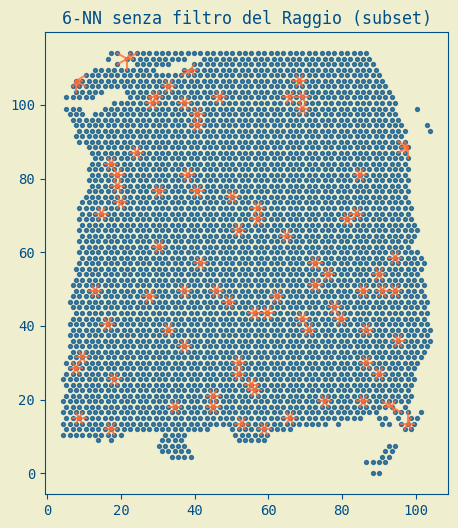

In [6]:
coords = index_to_cart  # shape: (n_spot, 2)
k = 1 + 6               # +1 perché include anche se stesso
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(coords)
dists, inds = nbrs.kneighbors(coords)

i = 0  # ad esempio: i = indice dello spot
vicini6 = inds[i, 1:]       # i 6 più vicini (salto se stesso)
distanze = dists[i, 1:]



np.random.seed(3)
sample = np.random.choice(len(coords), size=min(80, len(coords)), replace=False)

plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], s=8, alpha=0.7, facecolors=W, edgecolors=B, c=B)
for i in sample:
    for j in inds[i,1:]:
        plt.plot([coords[i,0], coords[j,0]], [coords[i,1], coords[j,1]], lw=1.4, alpha=0.8, color=Or)
plt.gca().set_aspect('equal'); plt.title('6-NN senza filtro del Raggio (subset)')
plt.savefig("presentazioneCerinelli/SpotViciniNonFiltratiPerRaggio", dpi=1000)
plt.show()

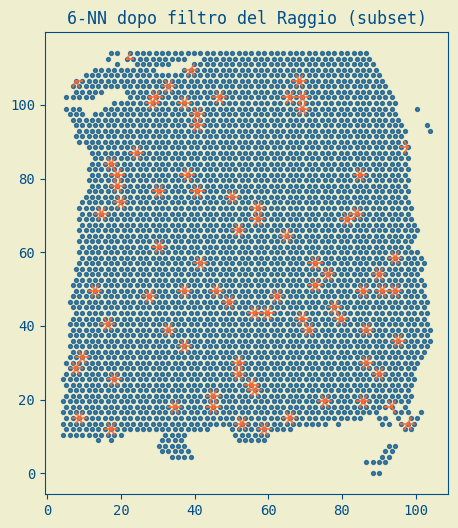

In [7]:
coords = index_to_cart  # shape: (n_spot, 2)
k = 1 + 6               # +1 perché include anche se stesso
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(coords)
dists, inds = nbrs.kneighbors(coords)

i = 0
vicini6 = inds[i, 1:]
distanze = dists[i, 1:]

# --- filtro per raggio ---
R = 1.74 

# liste di vicini/distanze filtrate per ogni nodo
vicini_filtrati  = []
distanze_filtrate = []

for i in range(len(coords)):
    di = dists[i, 1:]   # salta se stesso
    ii = inds[i, 1:]
    mask = di <= R      # "maggiore di R" viene rimosso
    vicini_filtrati.append(ii[mask])
    distanze_filtrate.append(di[mask])

np.random.seed(3)
sample = np.random.choice(len(coords), size=min(80, len(coords)), replace=False)

plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], s=8, alpha=0.7, facecolors=W, edgecolors=B, c=B)
for u in sample:
    for v in vicini_filtrati[u]:
        plt.plot([coords[u,0], coords[v,0]],
                 [coords[u,1], coords[v,1]],
                 lw=1.4, alpha=0.8,  color=Or)
plt.gca().set_aspect('equal'); plt.title('6-NN dopo filtro del Raggio (subset)')
plt.savefig("presentazioneCerinelli/SpotViciniFiltratiPerRaggio", dpi=1000)
plt.show()

In [8]:
print(vicini_filtrati[0])
print(inds[0])
print(vicini_filtrati[1])
print(inds[1])
#lo spot 0 ha vicini [1059, 3542,  485, 2121, 2329,  397], lo spot 1 ha vicini [1617, 2334,  692] ecc.. ecc...

[1059 3542  485 2121 2329  397]
[   0 1059 3542  485 2121 2329  397]
[1617 2334  692]
[   1 1617 2334  692 3106 1502  586]


In [9]:
binaryMasks = np.load("trasnformed_gdata.npy")  #tutte le binary mask dei 900 geni. 
                                                #mi dicono se nello spot 0 il gene è attivo o meno, 
                                                #se nello spot 1 il gene è attivo o meno ecc...

In [10]:
def labels_from_two_masks(maskA, maskB):
    A = (np.asarray(maskA) == 1)
    B = (np.asarray(maskB) == 1)
    labels = np.zeros_like(A, dtype=int)   # 0 = nessuno
    labels[np.where(A & ~B)] = 1           # 1 = solo A
    labels[np.where(~A & B)] = 2           # 2 = solo B
    labels[np.where(A & B)]  = 3           # 3 = A ∩ B
    return labels

def mask_to_set(mask):
    maskArray = np.asarray(mask)
    return set(np.flatnonzero(maskArray == 1)) #Mi torno gli indici (gli spot) in cui il gene è attivo

def are_touching(A_set, B_set, neighbors):
    count = 0
    if not A_set or not B_set:
        return False
    # itera l’insieme più piccolo, li scambio se B > A
    if len(A_set) > len(B_set):
        A_set, B_set = B_set, A_set
    for i in A_set:
        # se qualunque vicino i di A_set sta in B_set -> toccano
        if any((j in B_set) for j in neighbors[i]):
            count+=1
        
    if(count>50): #se più di 50 spot di A toccano gli spot di B, li considero adiacenti
        return True
    return False

def classify_relation_soft(maskA, maskB, neighbors,contain_tol=0.01):   # contain tol = tolleranaza. qua 1%
    A = mask_to_set(maskA) #Binary mask 1
    B = mask_to_set(maskB) #Binary mask 2


    inter = A & B #intersezione. es: A = {1,3,4}, B = {2,3,5} -> inter = {3}
    overlapA = (len(inter) / len(A)) if A else 0.0 #Quanti spot di A sono in B in %
    overlapB = (len(inter) / len(B)) if B else 0.0 #Quanti spot di B sono in A in %

    missA = len(A - B)  # quanti spot di A restano fuori da B (dilatato)
    missB = len(B - A)  # viceversa

    if len(A) > 0 and (missA / len(A) <= contain_tol):
        return ("A contenuto in B (tollerato)",
                {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB,
                 "missA": missA, "tol": contain_tol})

    if len(B) > 0 and (missB / len(B) <= contain_tol):
        return ("B contenuto in A (tollerato)",
                {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB,
                 "missB": missB, "tol": contain_tol})

    # --- casi rimanenti ---
    if inter and (overlapA > 0.3) and (overlapB > 0.3):
        return ("Parzialmente sovrapposti (overlap senza contenimento)",
                {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB})

    if are_touching(A, B, neighbors) and (overlapA < 0.03) and (overlapB < 0.03):
        return ("Si toccano (adiacenti, poco overlap)",
                {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB})

    return ("Disgiunti (poco overlap e adiacenza)",
            {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB})

('A contenuto in B (tollerato)', {'|A|': 1105, '|B|': 2370, '|A∩B|': 1097, 'overlapA': 0.9927601809954751, 'overlapB': 0.4628691983122363, 'missA': 8, 'tol': 0.01})


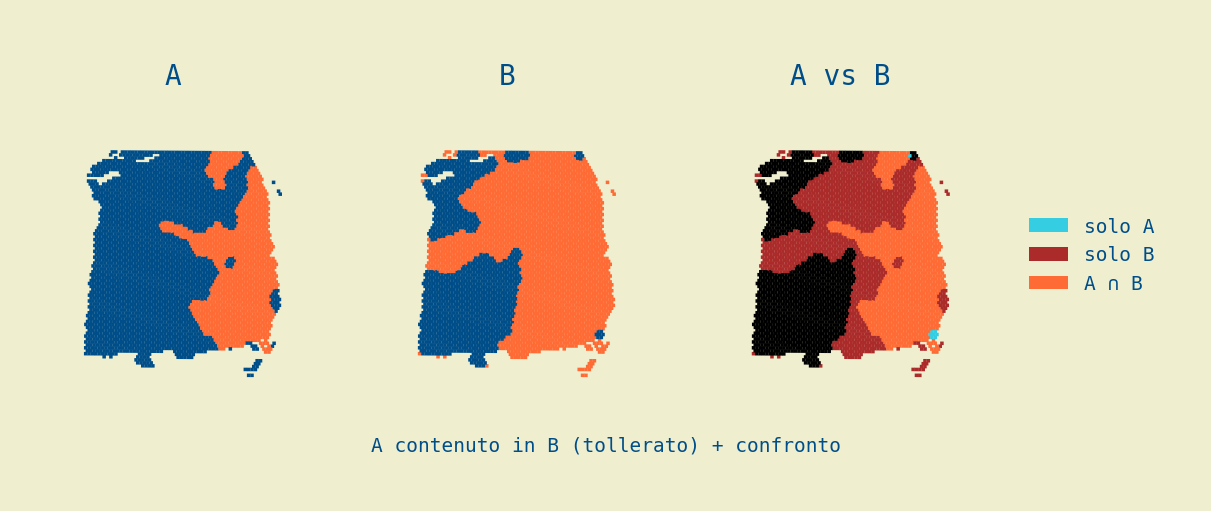

In [ ]:
binaryMask0 = binaryMasks[0]
binaryMask1 = binaryMasks[14]
print(classify_relation_soft(binaryMask0, binaryMask1,vicini_filtrati))

fig, (ax1, ax2, ax3,ax4) = plt.subplots(1, 4, figsize=(12, 5),
                                           gridspec_kw={"width_ratios":[1.2, 1.2, 1.2, 0.7]}, 
                                           constrained_layout=True)
array_data = scdata.X.toarray().T

plot_spatial_scatter(
    scdata, 
    binaryMask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A",)

plot_spatial_scatter(
    scdata, 
    binaryMask1, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "B")

fig.text(
    0.5, 0.1,
    "A contenuto in B (tollerato) + confronto", 
    ha="center", va="bottom"
)

labels = labels_from_two_masks(binaryMask0, binaryMask1)

plot_spatial_scatter(
    scdata,
    labels,                 # array 0..3
    cmap         = cmap_3,  # colormap discreta
    spines_color = W,
    size         = 1.5,
    shape        = "square",
    ax           = ax3,
    title        = "A vs B",
)

ax4.legend(handles=[
    Patch(facecolor=c1,   label="solo A"),
    Patch(facecolor=c2,   label="solo B"),
    Patch(facecolor=Or,   label="A ∩ B"),
], loc="center left", frameon=False)
ax4.axis('off')

plt.show()

('Disgiunti (poco overlap e adiacenza)', {'|A|': 882, '|B|': 1345, '|A∩B|': 148, 'overlapA': 0.16780045351473924, 'overlapB': 0.1100371747211896})


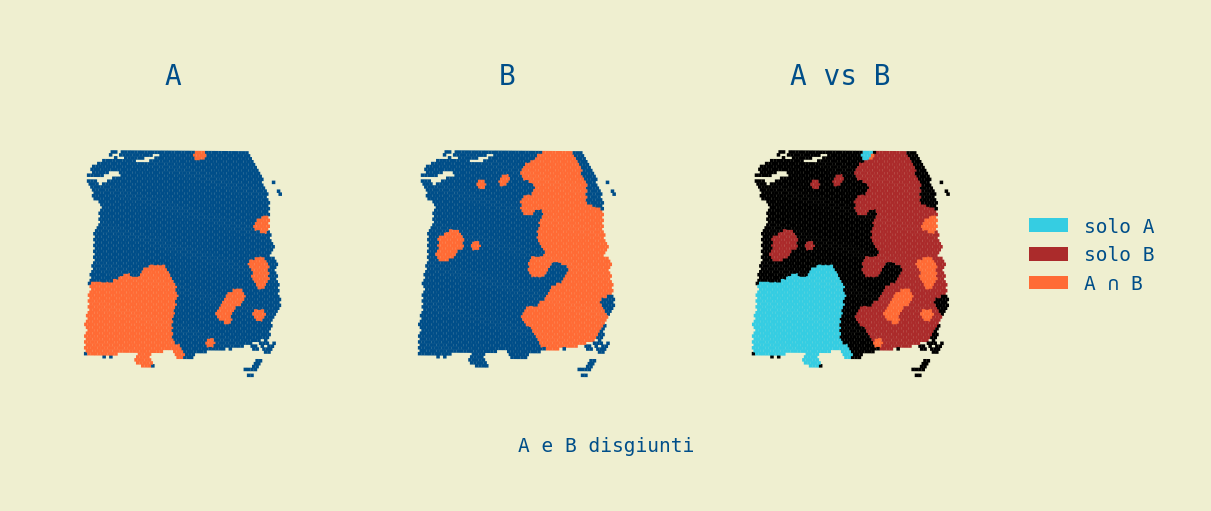

In [70]:
binaryMask0 = binaryMasks[7]
binaryMask1 = binaryMasks[143]

fig, (ax1, ax2, ax3,ax4) = plt.subplots(1, 4, figsize=(12, 5),
                                           gridspec_kw={"width_ratios":[1.2, 1.2, 1.2, 0.7]}, 
                                           constrained_layout=True)

plot_spatial_scatter(
    scdata, 
    binaryMask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A")

plot_spatial_scatter(
    scdata, 
    binaryMask1, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "B")

labels = labels_from_two_masks(binaryMask0, binaryMask1)

plot_spatial_scatter(
    scdata,
    labels,                 # array 0..3
    cmap         = cmap_3,  # colormap discreta
    spines_color = W,
    size         = 1.5,
    shape        = "square",
    ax           = ax3,
    title        = "A vs B",
)

ax4.legend(handles=[
    Patch(facecolor=c1,   label="solo A"),
    Patch(facecolor=c2,   label="solo B"),
    Patch(facecolor=Or,   label="A ∩ B"),
], loc="center left", frameon=False)
ax4.axis('off')

print(classify_relation_soft(binaryMask0, binaryMask1, vicini_filtrati))

fig.text(
    0.5, 0.1,
    "A e B disgiunti", 
    ha="center", va="bottom"
)
plt.show()

('B contenuto in A (tollerato)', {'|A|': 2700, '|B|': 1529, '|A∩B|': 1529, 'overlapA': 0.5662962962962963, 'overlapB': 1.0, 'missB': 0, 'tol': 0.01})


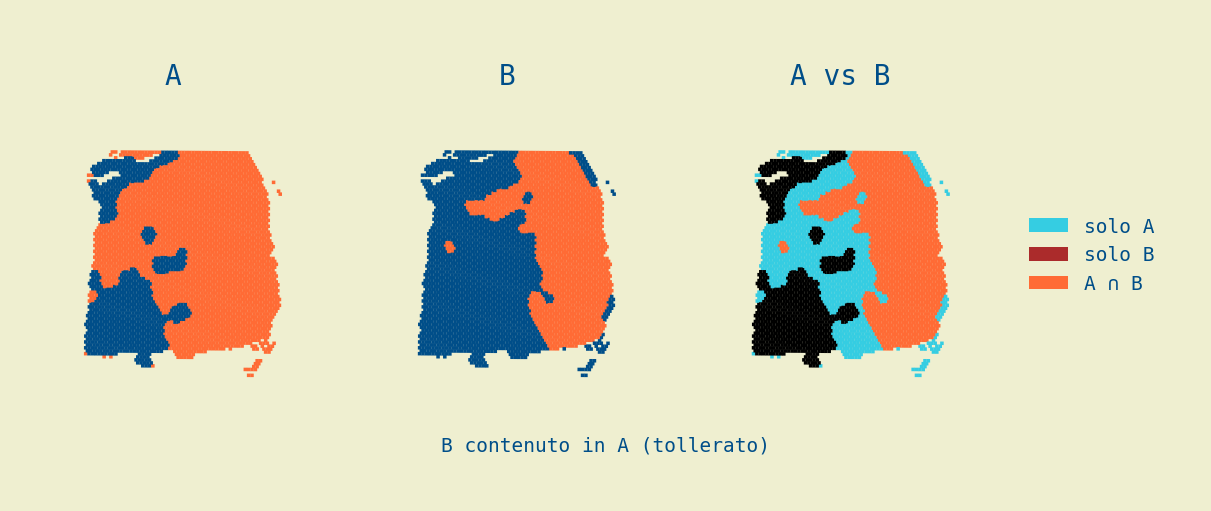

In [71]:
binaryMask0 = binaryMasks[56]
binaryMask1 = binaryMasks[112]

fig, (ax1, ax2, ax3,ax4) = plt.subplots(1, 4, figsize=(12, 5),
                                           gridspec_kw={"width_ratios":[1.2, 1.2, 1.2, 0.7]}, 
                                           constrained_layout=True)
array_data = scdata.X.toarray().T

plot_spatial_scatter(
    scdata, 
    binaryMask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A")

plot_spatial_scatter(
    scdata, 
    binaryMask1, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "B")

print(classify_relation_soft(binaryMask0, binaryMask1, vicini_filtrati))

fig.text(
    0.5, 0.1,
    "B contenuto in A (tollerato)", 
    ha="center", va="bottom"
)

labels = labels_from_two_masks(binaryMask0, binaryMask1)

plot_spatial_scatter(
    scdata,
    labels,                 # array 0..3
    cmap         = cmap_3,  # colormap discreta
    spines_color = W,
    size         = 1.5,
    shape        = "square",
    ax           = ax3,
    title        = "A vs B",
)

ax4.legend(handles=[
    Patch(facecolor=c1,   label="solo A"),
    Patch(facecolor=c2,   label="solo B"),
    Patch(facecolor=Or,   label="A ∩ B"),
], loc="center left", frameon=False)
ax4.axis('off')

plt.show()

In [90]:
for i in range(938):
    bA = binaryMasks[54]
    bB = binaryMasks[i]
    mask0 = mask_to_set(bA)
    mask14 = mask_to_set(bB)
    print(i,classify_relation_soft(bA, bB, vicini_filtrati))

0 ('Disgiunti (poco overlap e adiacenza)', {'|A|': 854, '|B|': 1105, '|A∩B|': 25, 'overlapA': 0.02927400468384075, 'overlapB': 0.02262443438914027})
1 ('Parzialmente sovrapposti (overlap senza contenimento)', {'|A|': 854, '|B|': 834, '|A∩B|': 701, 'overlapA': 0.8208430913348946, 'overlapB': 0.8405275779376499})
2 ('Disgiunti (poco overlap e adiacenza)', {'|A|': 854, '|B|': 2227, '|A∩B|': 85, 'overlapA': 0.09953161592505855, 'overlapB': 0.03816793893129771})
3 ('Disgiunti (poco overlap e adiacenza)', {'|A|': 854, '|B|': 1750, '|A∩B|': 71, 'overlapA': 0.08313817330210772, 'overlapB': 0.04057142857142857})
4 ('Parzialmente sovrapposti (overlap senza contenimento)', {'|A|': 854, '|B|': 967, '|A∩B|': 684, 'overlapA': 0.8009367681498829, 'overlapB': 0.7073422957600828})
5 ('Disgiunti (poco overlap e adiacenza)', {'|A|': 854, '|B|': 2407, '|A∩B|': 128, 'overlapA': 0.14988290398126464, 'overlapB': 0.05317823016202742})
6 ('Disgiunti (poco overlap e adiacenza)', {'|A|': 854, '|B|': 1175, '|A∩B|

('Disgiunti (poco overlap e adiacenza)', {'|A|': 967, '|B|': 2407, '|A∩B|': 324, 'overlapA': 0.33505687693898656, 'overlapB': 0.1346073950976319})


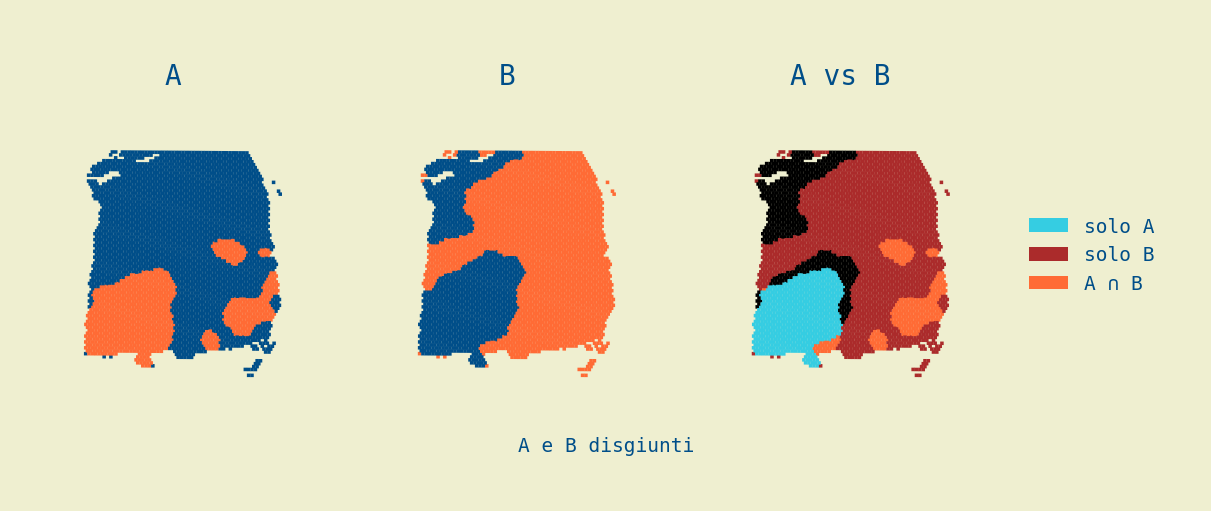

In [106]:
binaryMask0 = binaryMasks[4]
binaryMask1 = binaryMasks[5]

fig, (ax1, ax2, ax3,ax4) = plt.subplots(1, 4, figsize=(12, 5),
                                           gridspec_kw={"width_ratios":[1.2, 1.2, 1.2, 0.7]}, 
                                           constrained_layout=True)

plot_spatial_scatter(
    scdata, 
    binaryMask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A")

plot_spatial_scatter(
    scdata, 
    binaryMask1, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "B")


print(classify_relation_soft(binaryMask0, binaryMask1, vicini_filtrati))

fig.text(
    0.5, 0.1,
    "A e B disgiunti", # caso in cui non valgono perchè ho tanto overlap, ma non abbastanza per dire che sono sovrapposti,
                       # e troppo per dire che si toccano
    ha="center", va="bottom"
)

labels = labels_from_two_masks(binaryMask0, binaryMask1)

plot_spatial_scatter(
    scdata,
    labels,                 # array 0..3
    cmap         = cmap_3,  # colormap discreta
    spines_color = W,
    size         = 1.5,
    shape        = "square",
    ax           = ax3,
    title        = "A vs B",
)

ax4.legend(handles=[
    Patch(facecolor=c1,   label="solo A"),
    Patch(facecolor=c2,   label="solo B"),
    Patch(facecolor=Or,   label="A ∩ B"),
], loc="center left", frameon=False)
ax4.axis('off')

plt.show()

('Disgiunti (poco overlap e adiacenza)', {'|A|': 978, '|B|': 856, '|A∩B|': 38, 'overlapA': 0.03885480572597137, 'overlapB': 0.04439252336448598})


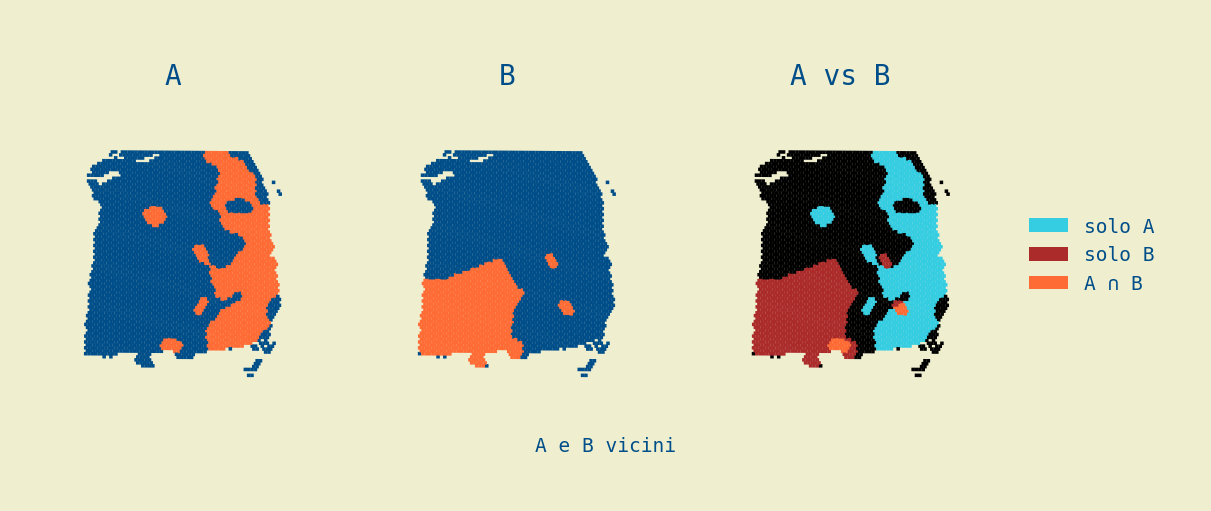

In [107]:
binaryMask0 = binaryMasks[184]
binaryMask1 = binaryMasks[185]

fig, (ax1, ax2, ax3,ax4) = plt.subplots(1, 4, figsize=(12, 5),
                                           gridspec_kw={"width_ratios":[1.2, 1.2, 1.2, 0.7]}, 
                                           constrained_layout=True)
plot_spatial_scatter(
    scdata, 
    binaryMask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A")

plot_spatial_scatter(
    scdata, 
    binaryMask1, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "B")

print(classify_relation_soft(binaryMask0, binaryMask1, vicini_filtrati))

fig.text(
    0.5, 0.1,
    "A e B vicini", 
    ha="center", va="bottom"
)

labels = labels_from_two_masks(binaryMask0, binaryMask1)

plot_spatial_scatter(
    scdata,
    labels,                 # array 0..3
    cmap         = cmap_3,  # colormap discreta
    spines_color = W,
    size         = 1.5,
    shape        = "square",
    ax           = ax3,
    title        = "A vs B",
)

ax4.legend(handles=[
    Patch(facecolor=c1,   label="solo A"),
    Patch(facecolor=c2,   label="solo B"),
    Patch(facecolor=Or,   label="A ∩ B"),
], loc="center left", frameon=False)
ax4.axis('off')

plt.show()

('Si toccano (adiacenti, poco overlap)', {'|A|': 1520, '|B|': 999, '|A∩B|': 27, 'overlapA': 0.017763157894736842, 'overlapB': 0.02702702702702703})


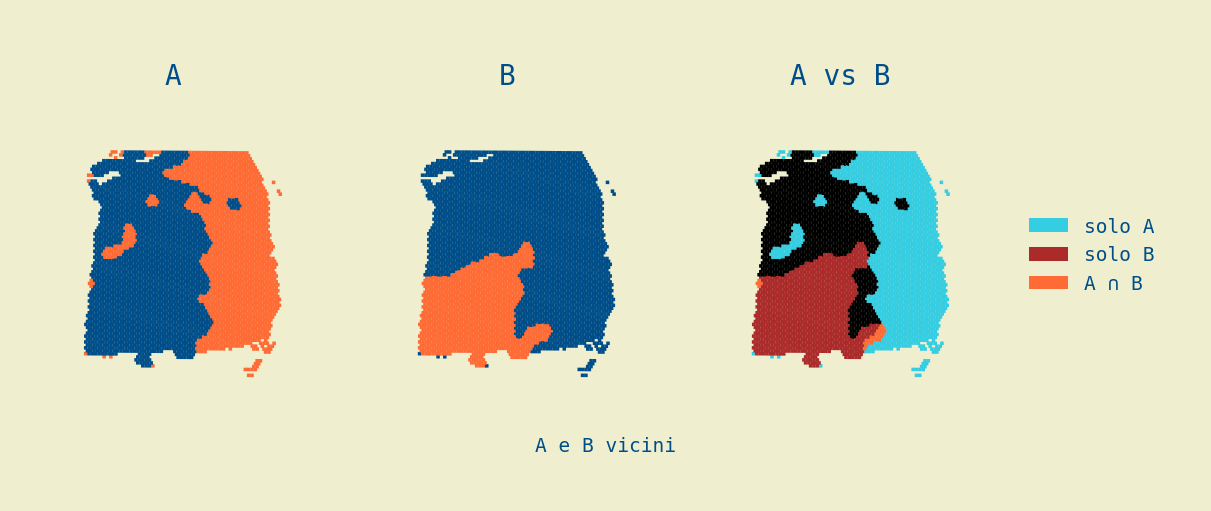

In [108]:
binaryMask0 = binaryMasks[124]
binaryMask1 = binaryMasks[171]

fig, (ax1, ax2, ax3,ax4) = plt.subplots(1, 4, figsize=(12, 5),
                                           gridspec_kw={"width_ratios":[1.2, 1.2, 1.2, 0.7]}, 
                                           constrained_layout=True)
plot_spatial_scatter(
    scdata, 
    binaryMask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A")

plot_spatial_scatter(
    scdata, 
    binaryMask1, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "B")

print(classify_relation_soft(binaryMask0, binaryMask1, vicini_filtrati))

fig.text(
    0.5, 0.1,
    "A e B vicini", 
    ha="center", va="bottom"
)

labels = labels_from_two_masks(binaryMask0, binaryMask1)

plot_spatial_scatter(
    scdata,
    labels,                 # array 0..3
    cmap         = cmap_3,  # colormap discreta
    spines_color = W,
    size         = 1.5,
    shape        = "square",
    ax           = ax3,
    title        = "A vs B",
)

ax4.legend(handles=[
    Patch(facecolor=c1,   label="solo A"),
    Patch(facecolor=c2,   label="solo B"),
    Patch(facecolor=Or,   label="A ∩ B"),
], loc="center left", frameon=False)
ax4.axis('off')

plt.show()

('Si toccano (adiacenti, poco overlap)', {'|A|': 1021, '|B|': 1007, '|A∩B|': 24, 'overlapA': 0.023506366307541625, 'overlapB': 0.023833167825223437})


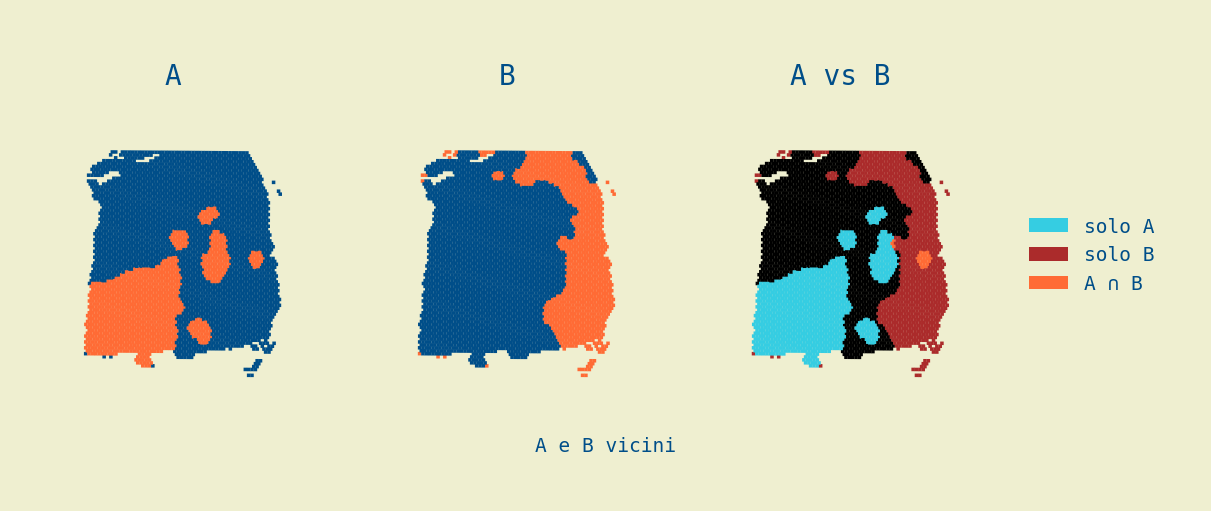

In [ ]:
binaryMask0 = binaryMasks[126]
binaryMask1 = binaryMasks[705]

fig, (ax1, ax2, ax3,ax4) = plt.subplots(1, 4, figsize=(12, 5),
                                           gridspec_kw={"width_ratios":[1.2, 1.2, 1.2, 0.7]}, 
                                           constrained_layout=True)
plot_spatial_scatter(
    scdata, 
    binaryMask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A")

plot_spatial_scatter(
    scdata, 
    binaryMask1, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "B")

print(classify_relation_soft(binaryMask0, binaryMask1, vicini_filtrati))

fig.text(
    0.5, 0.1,
    "A e B vicini", 
    ha="center", va="bottom"
)

labels = labels_from_two_masks(binaryMask0, binaryMask1)

plot_spatial_scatter(
    scdata,
    labels,                 # array 0..3
    cmap         = cmap_3,  # colormap discreta
    spines_color = W,
    size         = 1.5,
    shape        = "square",
    ax           = ax3,
    title        = "A vs B",
)

ax4.legend(handles=[
    Patch(facecolor=c1,   label="solo A"),
    Patch(facecolor=c2,   label="solo B"),
    Patch(facecolor=Or,   label="A ∩ B"),
], loc="center left", frameon=False)
ax4.axis('off')

plt.show()

('Parzialmente sovrapposti (overlap senza contenimento)', {'|A|': 1030, '|B|': 917, '|A∩B|': 833, 'overlapA': 0.8087378640776699, 'overlapB': 0.9083969465648855})


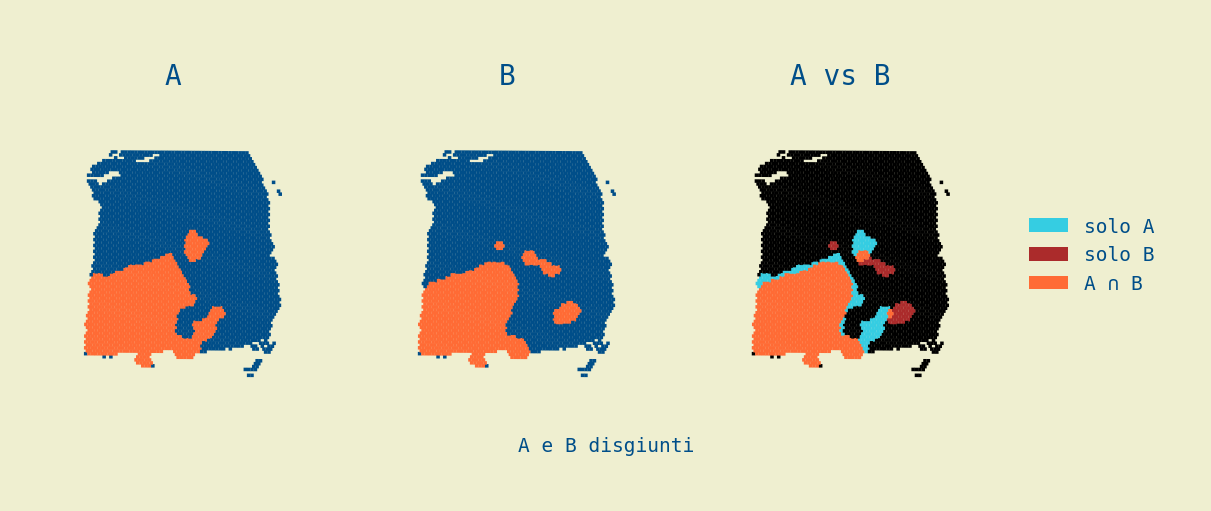

In [ ]:
#Caso contenuto o disgiunto???
binaryMask0 = binaryMasks[126]
binaryMask1 = binaryMasks[255]

fig, (ax1, ax2, ax3,ax4) = plt.subplots(1, 4, figsize=(12, 5),
                                           gridspec_kw={"width_ratios":[1.2, 1.2, 1.2, 0.7]}, 
                                           constrained_layout=True)
plot_spatial_scatter(
    scdata, 
    binaryMask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A")

plot_spatial_scatter(
    scdata, 
    binaryMask1, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "B")

print(classify_relation_soft(binaryMask0, binaryMask1, vicini_filtrati))

fig.text(
    0.5, 0.1,
    "A e B disgiunti", 
    ha="center", va="bottom"
)

labels = labels_from_two_masks(binaryMask0, binaryMask1)

plot_spatial_scatter(
    scdata,
    labels,                 # array 0..3
    cmap         = cmap_3,  # colormap discreta
    spines_color = W,
    size         = 1.5,
    shape        = "square",
    ax           = ax3,
    title        = "A vs B",
)

ax4.legend(handles=[
    Patch(facecolor=c1,   label="solo A"),
    Patch(facecolor=c2,   label="solo B"),
    Patch(facecolor=Or,   label="A ∩ B"),
], loc="center left", frameon=False)
ax4.axis('off')

plt.show()

In [19]:
#Funzione di classificazione ma senza le varie informazioni. Mi serve per fare la tabella di adiacenza.

def classify_relation_soft_matrix(maskA, maskB, neighbors,contain_tol=0.01):   # contain tol = tolleranaza. qua 1%
    A = mask_to_set(maskA) #Binary mask 1
    B = mask_to_set(maskB) #Binary mask 2


    inter = A & B #intersezione. es: A = {1,3,4}, B = {2,3,5} -> inter = {3}
    overlapA = (len(inter) / len(A)) if A else 0.0 #Quanti spot di A sono in B in %
    overlapB = (len(inter) / len(B)) if B else 0.0 #Quanti spot di B sono in A in %

    missA = len(A - B)  # quanti spot di A restano fuori da B (dilatato)
    missB = len(B - A)  # viceversa

    if len(A) > 0 and (missA / len(A) <= contain_tol):
        return ("CONTENUTO")

    if len(B) > 0 and (missB / len(B) <= contain_tol):
        return ("CONTENUTO")

    # --- casi rimanenti ---
    if inter and (overlapA > 0.3) and (overlapB > 0.3):
        return ("IN_COSTA") #Parzialmente sovrapposti (overlap senza contenimento)

    if are_touching(A, B, neighbors) and (overlapA < 0.03) and (overlapB < 0.03):
        return ("VICINI")

    return ("DISGIUNTI")

In [ ]:
array_matrix = np.empty((len(binaryMasks), len(binaryMasks)), dtype=object)

n = len(binaryMasks)
array_matrix = np.empty((n, n), dtype=object)

for i in range(n):
    array_matrix[i, i] = "STESSO_GENE"
    for j in range(i + 1, n):
        # calcola una sola volta
        val = classify_relation_soft_matrix(binaryMasks[i], binaryMasks[j], vicini_filtrati)
        if(val == "VICINI"):
            print(i, j)
        # assegna simmetricamente
        array_matrix[i, j] = val
        array_matrix[j, i] = val

In [89]:
for i in range(n):
    for j in range(i + 1, n):
        # calcola una sola volta
        if(array_matrix[i, j] == "VICINI"):
            print(i, j)


54 874
68 116
68 203
68 700
99 194
99 903
106 194
116 528
116 874
124 171
126 254
126 264
126 528
126 705
156 246
156 504
161 198
171 390
171 420
171 469
171 572
192 194
194 399
194 499
194 597
194 675
194 703
194 731
194 781
194 795
194 817
194 841
194 859
194 879
194 908
203 307
203 817
217 810
235 682
240 642
255 874
282 810
322 810
328 807
348 874
366 810
394 437
394 843
400 461
420 810
437 523
437 682
437 832
461 590
469 807
469 868
504 841
504 850
513 597
556 874
579 874
590 716
609 655
614 810
738 810
784 874
807 874
810 920
841 892
842 874
846 874
874 903


In [84]:
np.save("adjacency_matrix.npy", array_matrix, allow_pickle=True)

In [126]:


adjacency_matrix = np.load("adjacency_matrix.npy", allow_pickle=True)
n = adjacency_matrix.shape[0]

gene_ids = list(range(n))

G = nx.Graph()
# aggiungi nodi con l'attributo 'label' = ID gene
for i in range(n):
    G.add_node(i, label=str(gene_ids[i]))

# aggiungi archi per coppie con relazione utile
valid_edges = {"CONTENUTO", "IN_COSTA", "VICINI", "DISGIUNTI"}  # escludo STESSO_GENE e DISGIUNTI
for i in range(n):
    for j in range(i+1, n):
        rel = adjacency_matrix[i, j]
        if rel in valid_edges:
            G.add_edge(i, j, relation=rel)


In [86]:
# mappa colori per relazione
edge_color_map = {
    "CONTENUTO": "#2ca02c",  # verde
    "IN_COSTA":  "#ff7f0e",  # arancione
    "VICINI":    "#1f77b4",  # blu
    "DISGIUNTI": "#cf2ad4"
}

# estrai colori edge in ordine coerente a G.edges()
edge_colors = [edge_color_map[G[u][v]["relation"]] for u, v in G.edges()]

In [ ]:
# w = {"CONTENUTO": 3.0, "IN_COSTA": 2.0, "VICINI": 1.0,"DISGIUNTI": 0.1}
# for u,v in G.edges():
#     G[u][v]["weight"] = w[G[u][v]["relation"]]

#pos = nx.spring_layout(G, seed=42, weight="weight", k=0.15, iterations=300)
pos = nx.kamada_kawai_layout(G)
plt.figure(figsize=(12, 10))

# nodi (senza etichette per evitare caos)
nx.draw_networkx_nodes(G, pos, node_size=40, node_color="#004e89", alpha=0.8)

# archi colorati per relazione
nx.draw_networkx_edges(G, pos, edgelist=list(G.edges()), edge_color=edge_colors, width=0.7, alpha=0.7)

# opzionale: poche etichette per i nodi più connessi
# prendi i top-k per grado


# legenda manuale
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color=edge_color_map["CONTENUTO"], lw=2, label="CONTENUTO"),
    Line2D([0], [0], color=edge_color_map["IN_COSTA"],  lw=2, label="IN_COSTA"),
    Line2D([0], [0], color=edge_color_map["VICINI"],    lw=2, label="VICINI"),
    Line2D([0], [0], color=edge_color_map["DISGIUNTI"],    lw=2, label="DISGIUNTI"),
]
plt.legend(handles=legend_elems, loc="upper right", frameon=False)

plt.axis("off")
plt.title("Grafo dei geni con relazioni")
plt.tight_layout()
plt.show()


N nodi (con almeno un arco VICINI): 77   N archi VICINI: 72


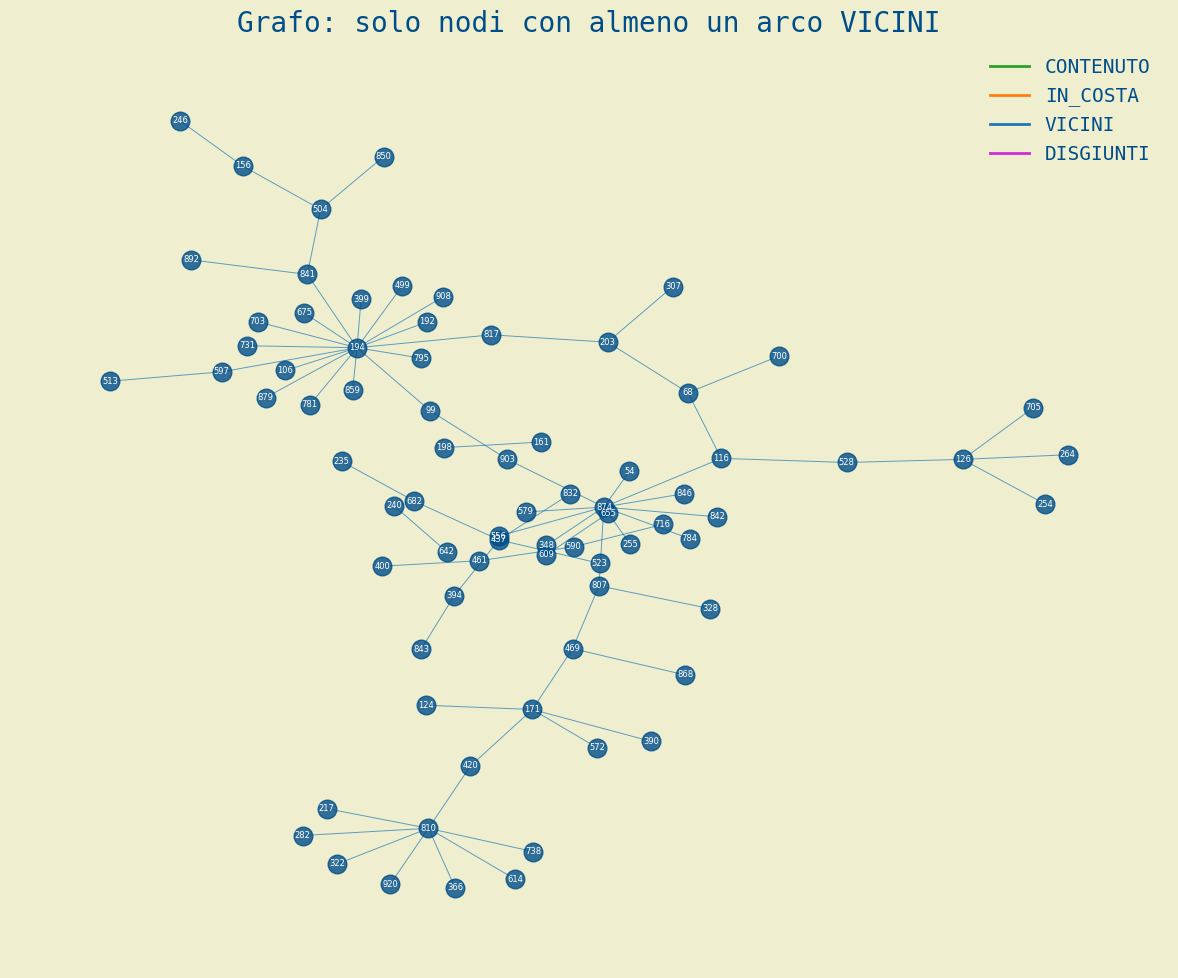

In [124]:

n = adjacency_matrix.shape[0]
gene_ids = list(range(n))  # oppure i tuoi ID reali

# 1) Costruisci SOLO gli archi "VICINI"
E_vicini = []
for i in range(n):
    for j in range(i+1, n):
        rel = str(adjacency_matrix[i, j]).strip()
        if rel == "VICINI":
            E_vicini.append((i, j))

# 2) Crea il grafo solo con quegli archi (nodi = solo quelli che compaiono in E_vicini)
G = nx.Graph()
G.add_edges_from(E_vicini)
nx.set_node_attributes(G, {u: str(gene_ids[u]) for u in G.nodes()}, "label")

print("N nodi (con almeno un arco VICINI):", G.number_of_nodes(),
      "  N archi VICINI:", G.number_of_edges())

# 3) Layout e plot
k = 1.9 / np.sqrt(n)   # ↑ più grande = nodi più lontani (default ≈ 1/√n)
pos = nx.kamada_kawai_layout(G)
plt.figure(figsize=(12,10))

nx.draw_networkx_nodes(G, pos, node_size=180, node_color="#004e89", alpha=0.8,)
nx.draw_networkx_edges(G, pos, edgelist=list(G.edges()),
                       edge_color="#1f77b4", width=0.7, alpha=0.7)


labels = nx.get_node_attributes(G, "label")   # {node: "id_str"}
nx.draw_networkx_labels(
    G, pos,
    labels=labels,
    font_size=6,            # ↑ se vuoi testo più grande
    font_color="white",     # contrasta con #004e89
    verticalalignment="center",
    horizontalalignment="center"
)

legend_elems = [
    Line2D([0], [0], color=edge_color_map["CONTENUTO"], lw=2, label="CONTENUTO"),
    Line2D([0], [0], color=edge_color_map["IN_COSTA"],  lw=2, label="IN_COSTA"),
    Line2D([0], [0], color=edge_color_map["VICINI"],    lw=2, label="VICINI"),
    Line2D([0], [0], color=edge_color_map["DISGIUNTI"],    lw=2, label="DISGIUNTI"),
]
plt.legend(handles=legend_elems, loc="upper right", frameon=False)

plt.axis("off")
plt.title("Grafo: solo nodi con almeno un arco VICINI")
plt.tight_layout()
plt.show()
